# FAPE, SBA Agricultural Loans Fairness Intervention: ThresholdOptimizer

Phase 4, fairness intervention (Stage 3 of the framework) in the agricultural/financial domain, on SBA 7(a) agricultural loans from FY1991 to FY2024 (15,845 records, 5.2% default rate). The script applies Fairlearn's ThresholdOptimizer post-processing to the baseline models under the demographic parity and equalized odds constraints. The primary sensitive attribute is `businesstype` (0 = Corporation, 1 = Individual, 2 = Partnership), and records with an unknown business type (-1, n=34) are excluded from the fairness metrics; `borrstate` gives a secondary, state-level view. The data has no race or gender field, so the audit uses business type. The positive class is Charged Off, so the partnership-to-corporation DIR compares predicted default rates: 1.0 is parity and the side away from 1.0 is adverse to that group. ThresholdOptimizer.predict is seeded with random_state=42, so runs are identical.

Code: `src/stage2_agricultural_threshold.py`. This notebook runs that script, so its printed output and figures are the ones the paper uses.

In [1]:
import os, sys, warnings, logging

# The data loaders read paths relative to the repository root (data/raw/...), so run from there.
# The check stops a second run of this cell from moving up another directory.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
if os.path.abspath('src') not in sys.path:
    sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
from IPython.display import Image, display

# matplotlib 3.8.4 (pinned) imports backend2gui from IPython when a script makes its first figure
# inside a kernel, and IPython 9 removed it. An empty mapping is what IPython 8 gave for Agg.
import IPython.core.pylabtools
if not hasattr(IPython.core.pylabtools, 'backend2gui'):
    IPython.core.pylabtools.backend2gui = {}

In [2]:
from stage2_agricultural_threshold import run_stage2

run_stage2();  # returns (baseline, dp_results, eo_results, btype_test); the semicolon keeps Jupyter from echoing it

FAPE Phase 4, Agricultural Fairness Intervention: ThresholdOptimizer
Loading SBA 7(a) agricultural loans, FY1991 onward...


  FY1991-1999: 337,033 total | 4,445 agricultural NAICS-11


  FY2000-2009: 690,333 total | 4,931 agricultural NAICS-11


  FY2010-2019: 545,751 total | 8,632 agricultural NAICS-11


  FY2020-Present: 373,981 total | 3,918 agricultural NAICS-11
  Combined agricultural records: 21,926
  After binary outcome filter: 15,845

  Loan status distribution:
    Paid In Full: 15,015
    Charged Off:  830

  Top agricultural NAICS categories:
naicsdescription
Broilers and Other Meat Type Chicken Production     6335
Logging                                             1756
Support Activities for Animal Production            1097
Chicken Egg Production                               946
Broilers and Other Meat Type Chicken Production      853

  OK: sba_agricultural: 15,845 records | 8 features | default rate: 0.052

  n=15,811 | default_rate=5.2% | severe imbalance
  Primary sensitive: businesstype (0=Corp 1=Individual 2=Partnership)
  Note: No race or gender field; the audit uses business type
  Note: ThresholdOptimizer.predict seeded with random_state=42

--- Baseline Results (unconstrained models) ---
  LogisticRegression        AUC=0.727 DP_diff=0.005 EO_diff=0.005


...

Loading SBA 7(a) agricultural loans, FY1991 onward...


  FY1991-1999: 337,033 total | 4,445 agricultural NAICS-11


  FY2000-2009: 690,333 total | 4,931 agricultural NAICS-11


  FY2010-2019: 545,751 total | 8,632 agricultural NAICS-11


  FY2020-Present: 373,981 total | 3,918 agricultural NAICS-11
  Combined agricultural records: 21,926
  After binary outcome filter: 15,845

  Loan status distribution:
    Paid In Full: 15,015
    Charged Off:  830

  Top agricultural NAICS categories:
naicsdescription
Broilers and Other Meat Type Chicken Production     6335
Logging                                             1756
Support Activities for Animal Production            1097
Chicken Egg Production                               946
Broilers and Other Meat Type Chicken Production      853

  OK: sba_agricultural: 15,845 records | 8 features | default rate: 0.052
  Fig 8 saved, agricultural_state_prediction_rates.png
  States analyzed: 40 | max-min gap: 0.160

--- Agricultural intervention complete ---
  8 figures saved to figures/stage2/
  Business type fairness intervention applied


## 1. Accuracy and DPD, baseline and constrained

Accuracy and business-type demographic parity difference for each model at baseline and under each constraint.

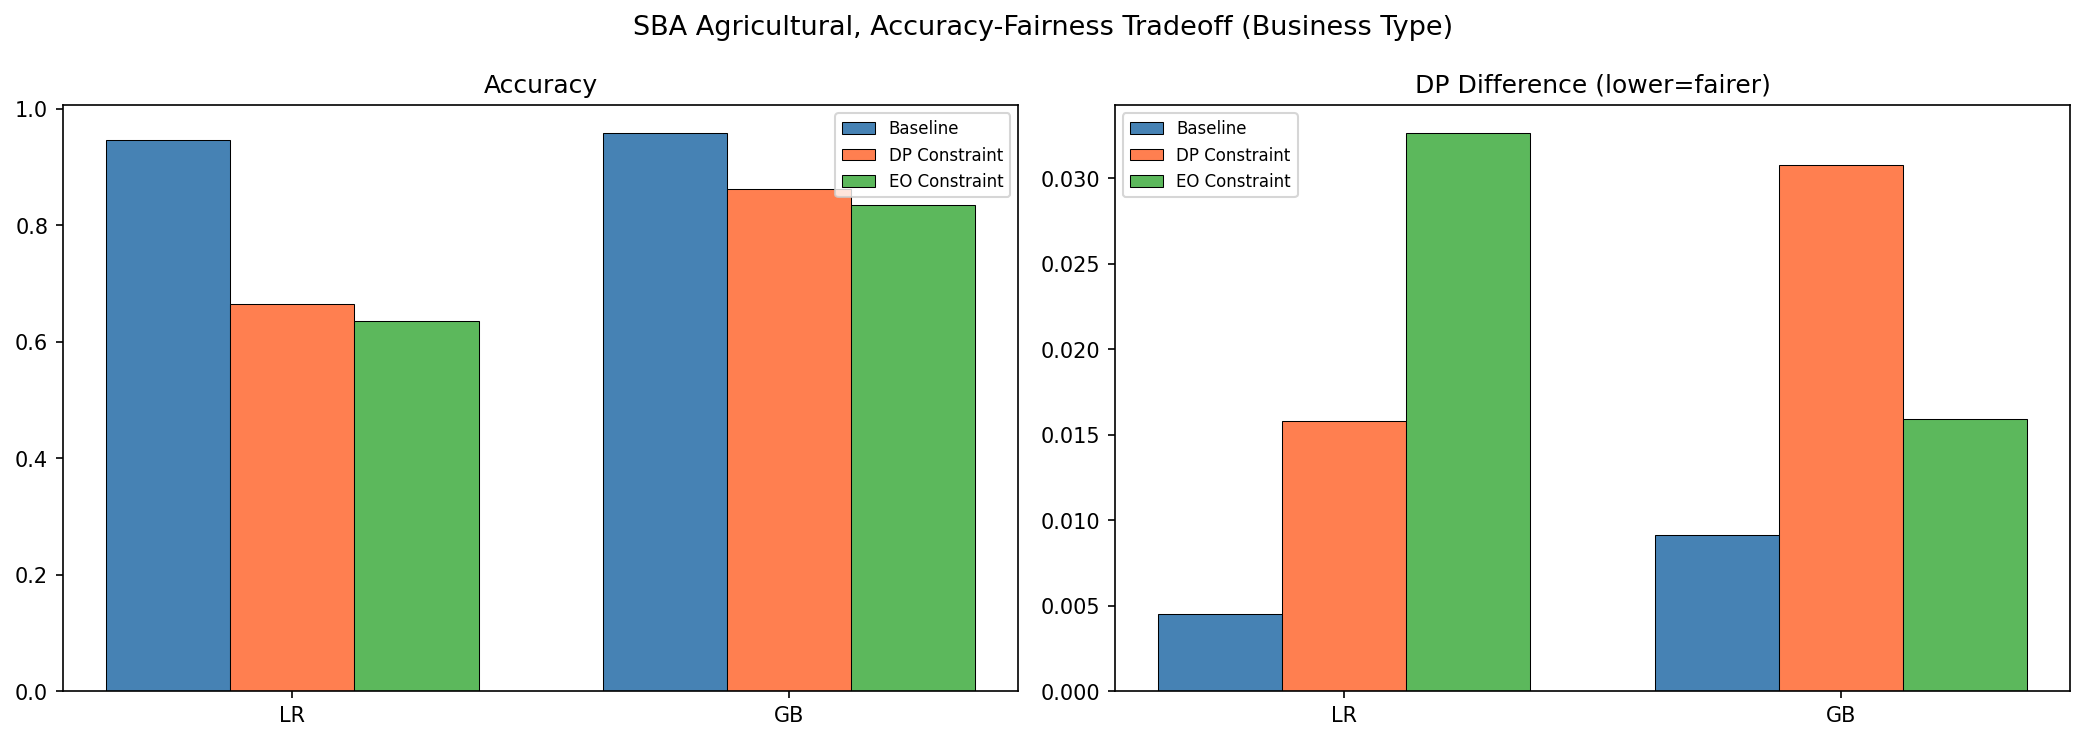

In [3]:
display(Image('figures/stage2/agricultural_accuracy_fairness_tradeoff.png'))

## 2. Fairness improvement by constraint

Change in business-type DPD under the demographic parity constraint and in EOD under the equalized odds constraint, for each model.

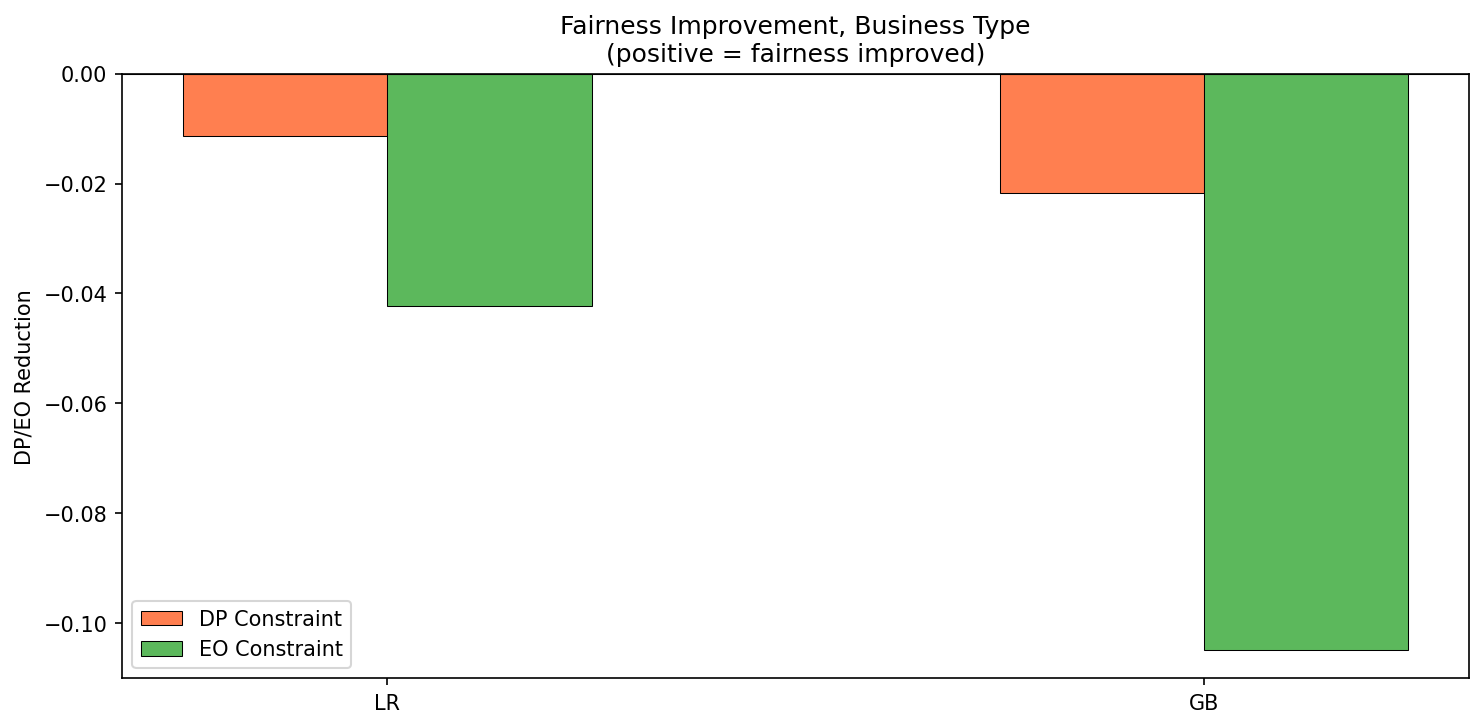

In [4]:
display(Image('figures/stage2/agricultural_fairness_improvement.png'))

## 3. Accuracy cost against fairness gain

Each model's accuracy cost plotted against its fairness gain under each constraint.

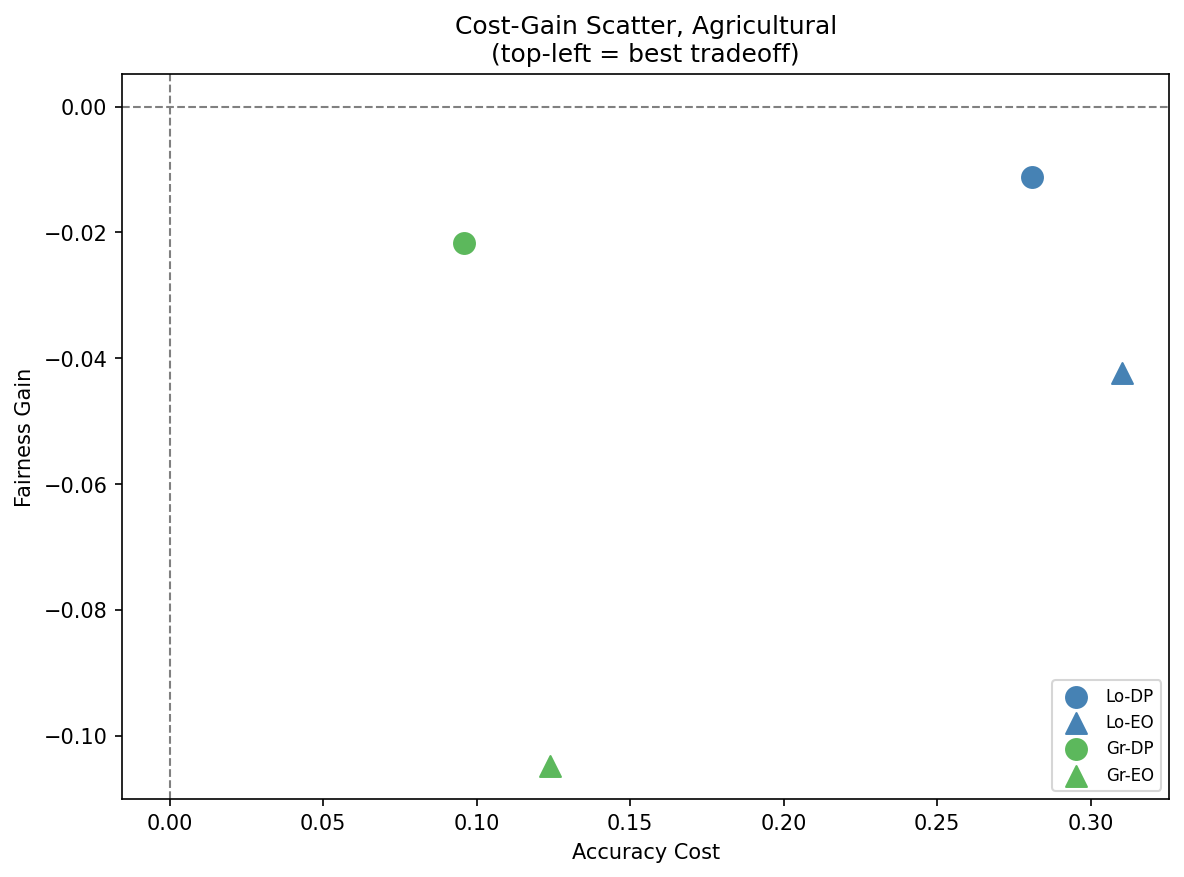

In [5]:
display(Image('figures/stage2/agricultural_cost_gain_scatter.png'))

## 4. Predicted default rates by business type

Gradient boosting's predicted default rate for corporations, individuals and partnerships, before and after the demographic parity constraint.

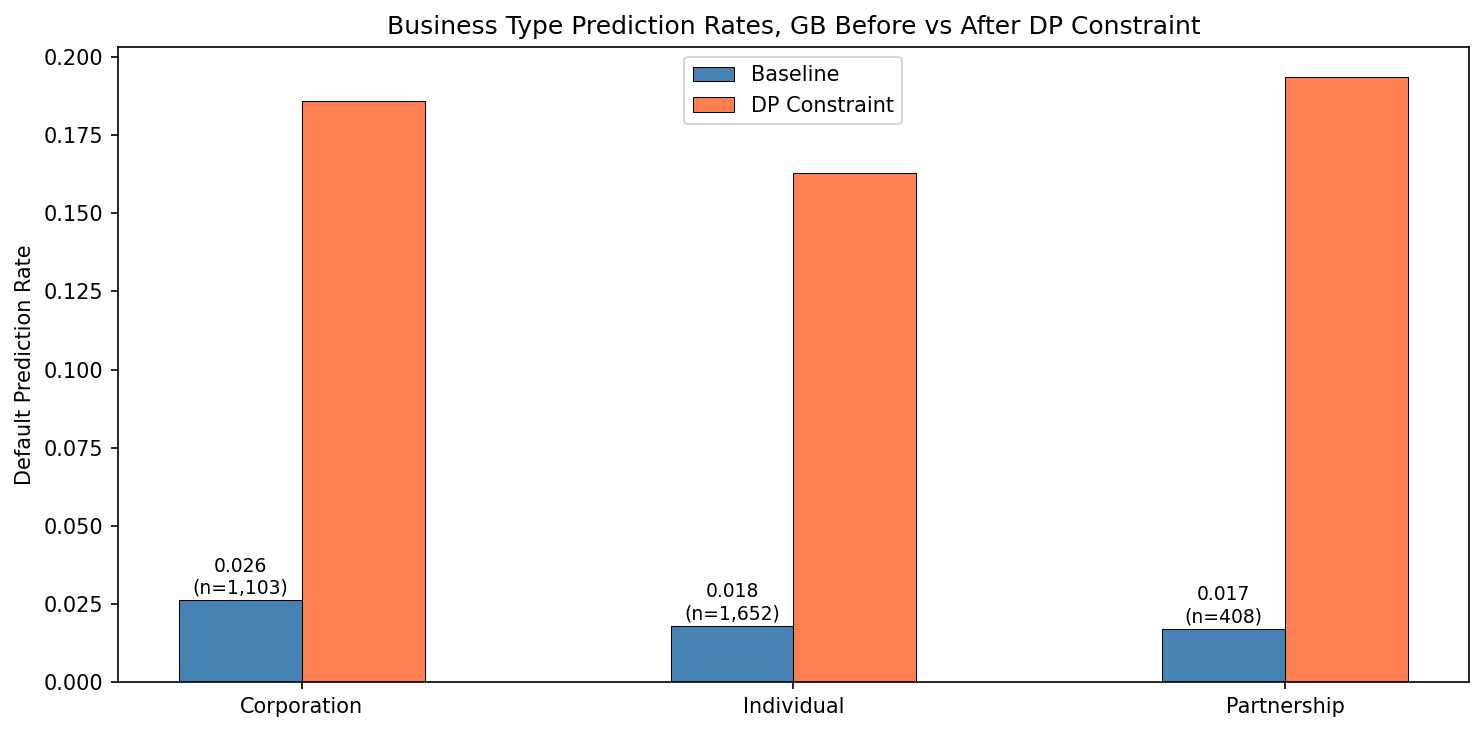

In [6]:
display(Image('figures/stage2/agricultural_btype_prediction_rates.png'))

## 5. Partnership-to-corporation DIR

Ratio of partnership to corporation predicted default rates for each model, before and after the demographic parity constraint.

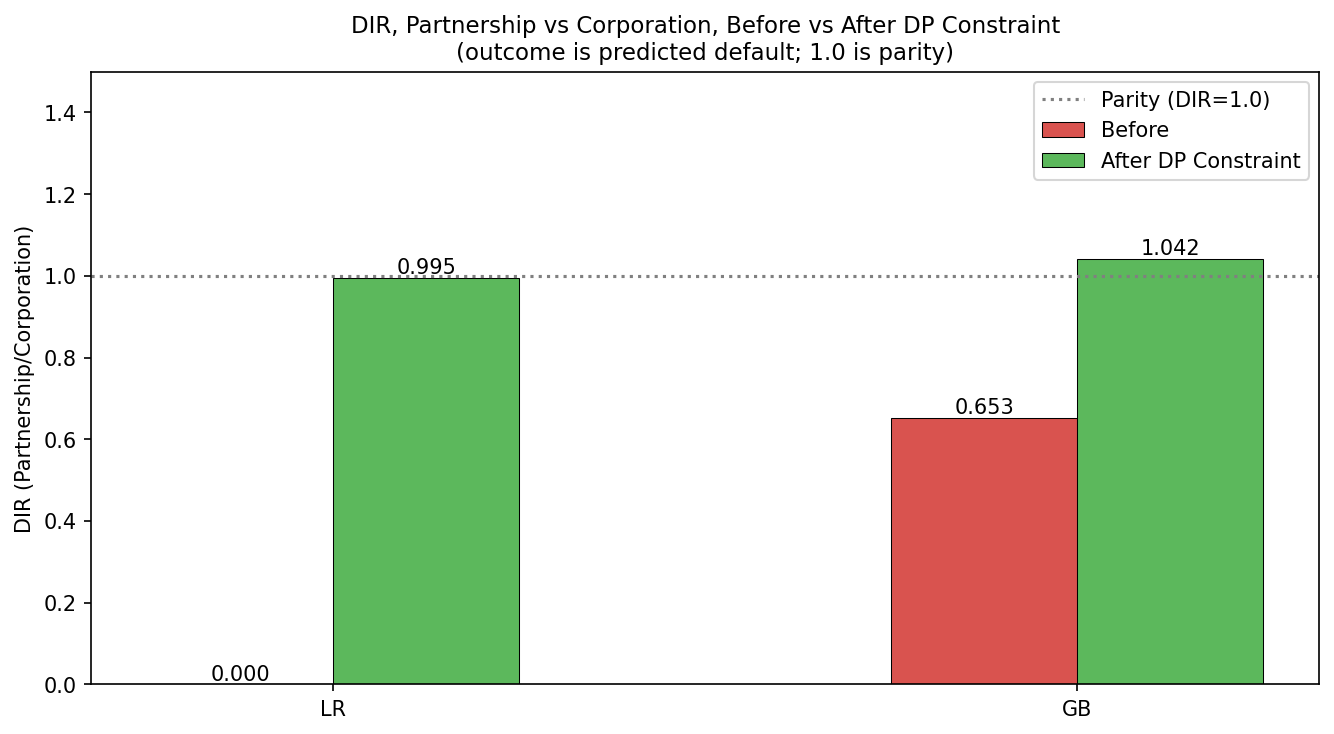

In [7]:
display(Image('figures/stage2/agricultural_dir_before_after.png'))

## 6. F1 comparison

F1 score for each model at baseline and under the demographic parity constraint.

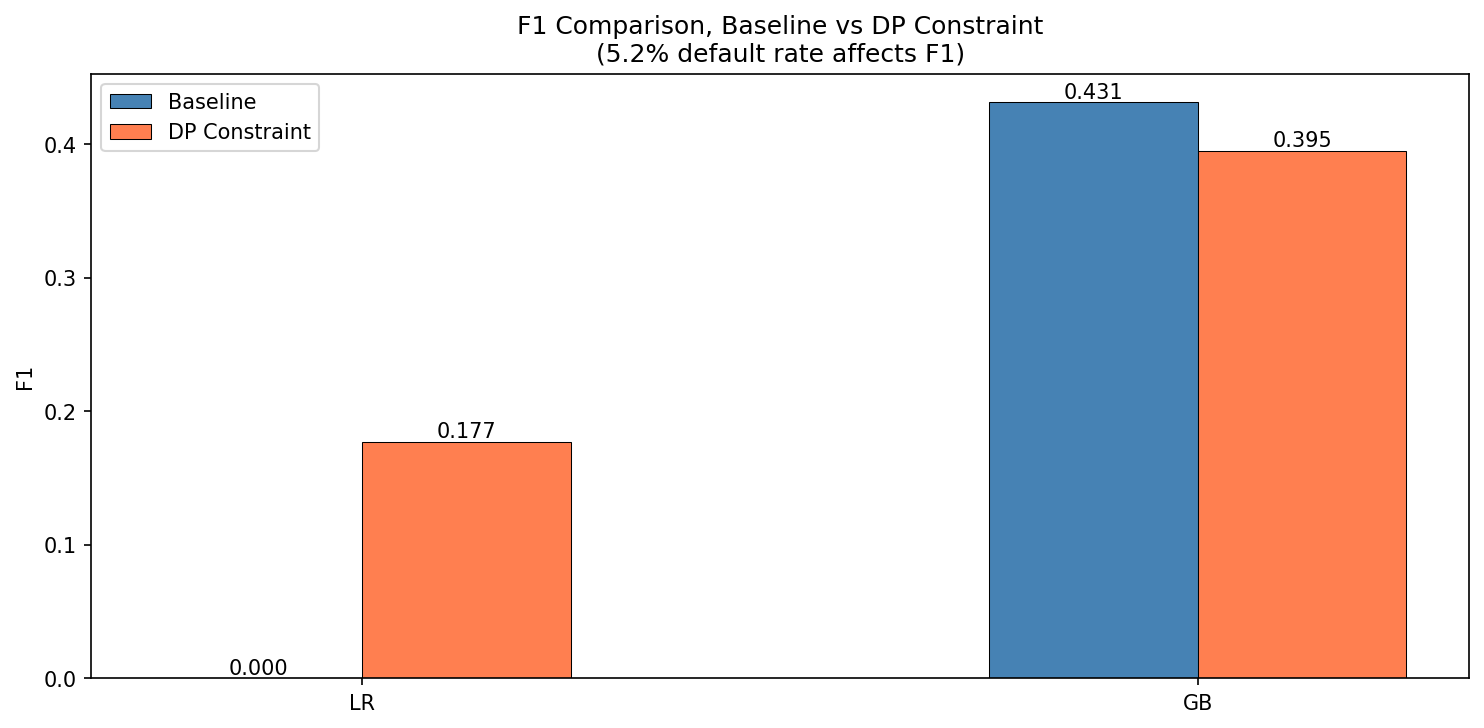

In [8]:
display(Image('figures/stage2/agricultural_f1_comparison.png'))

## 7. FPR and FNR by business type

Gradient boosting's false positive and false negative rates by business type, at baseline and under the demographic parity constraint.

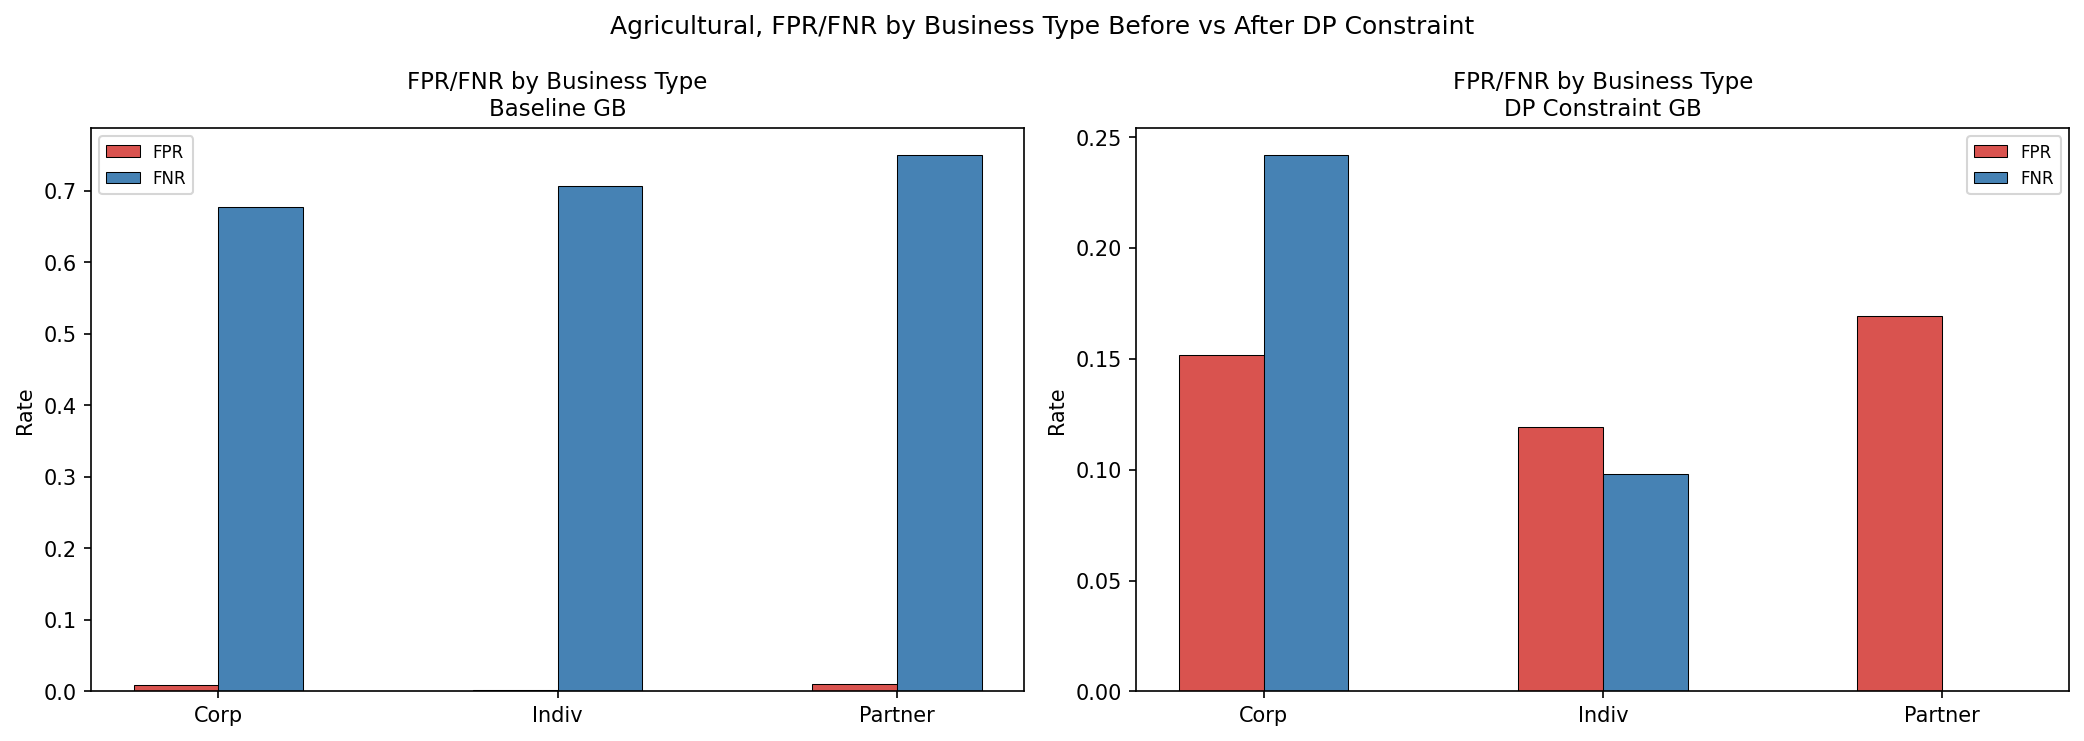

In [9]:
display(Image('figures/stage2/agricultural_fpr_fnr_by_btype.png'))

## 8. Predicted default rates by state

The states with the highest baseline gradient boosting predicted default rates, shown against the overall mean.

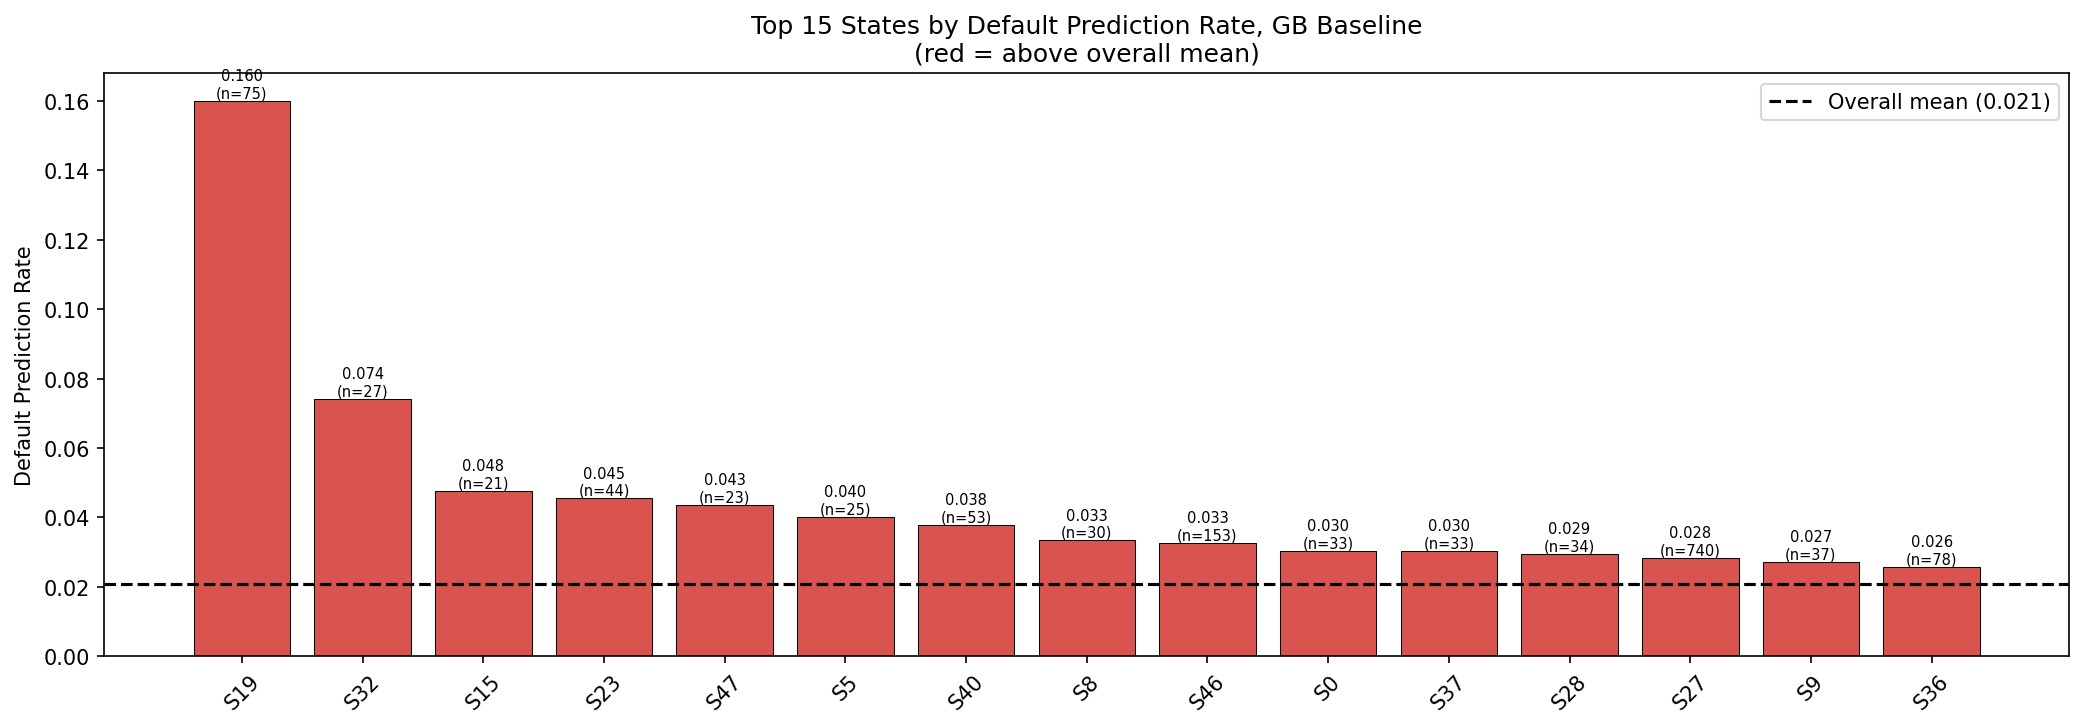

In [10]:
display(Image('figures/stage2/agricultural_state_prediction_rates.png'))

## Printed findings

The script's computed findings are in the output of the run cell above.